# Plotting Geant4 Simulation Results

This notebook includes code to 
- plot energy spectra for different calibration tube distances for the 228Th, 241Am, 133Ba calibration sources.
- count the total number of counts in the peaks used in calibration are counted for each distance using sideband subtraction.
- count total detected number of counts at each distance.

In [6]:
from lgdo import lh5
import awkward as ak
import hist
import matplotlib.pyplot as plt


def plot_edep(detid, bins, xmin, xmax, filename):
    '''
    read the data from detector "detid". pass all 8 files to concatenate them
    view it as and Awkward Array
    '''
    data = lh5.read_as(f"stp/{detid}", filename, "ak") 

    # make and plot an histogram
    hist.new.Reg(bins, xmin, xmax, name="Energy [keV]").Double().fill(
        ak.sum(data.edep, axis=-1)
    ).plot(yerr=False, label=detid)


def side_band_subtract(lower_peak, upper_peak, band_amount, filename, detid):
    
    data = lh5.read_as(f"stp/{detid}", filename, "ak")
    energies = ak.sum(data.edep, axis=-1)

    peak_mask = (energies > lower_peak) & (energies < upper_peak)
    total = sum(peak_mask)

    left_mask = (energies > lower_peak - band_amount) & (energies < lower_peak)
    left_counts = sum(left_mask)

    right_mask = (energies > upper_peak) & (energies < upper_peak + band_amount)
    right_counts = sum(right_mask)

    background = (left_counts + right_counts) / (band_amount * 2)

    peak_counts = total - background

    return peak_counts

def total_counts(detid, filename):
    data = lh5.read_as(f"stp/{detid}/evtid", filename, "ak")
    return len(data)


## Thorium-228

In [7]:
thorium_filepath = "/Users/vyshnavisabbi/Documents/latte_geant4/simulation_data/Thorium/" # path where lh5 files are located

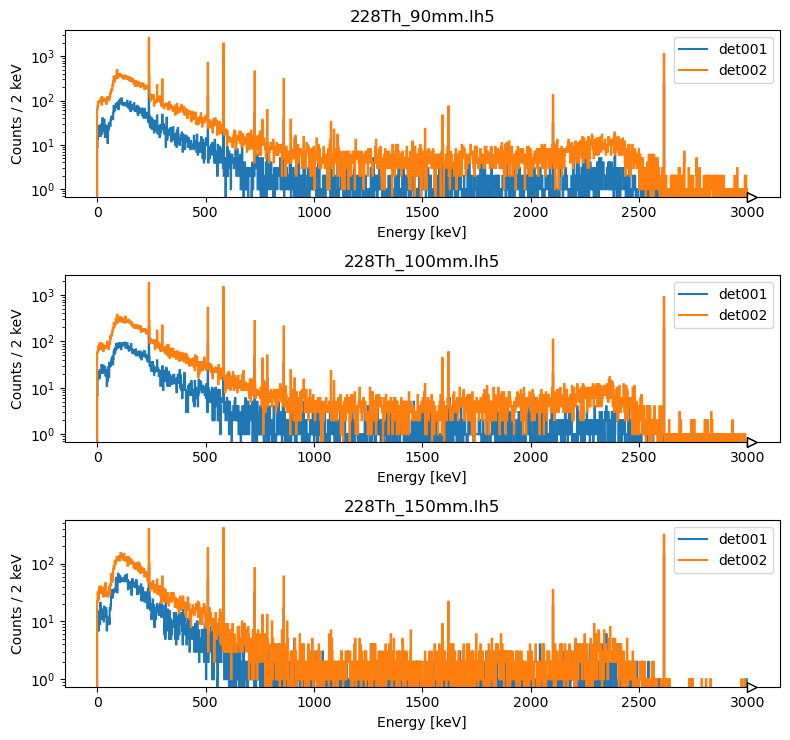

In [8]:
files = ["228Th_90mm.lh5", "228Th_100mm.lh5", "228Th_150mm.lh5"]

fig, axes = plt.subplots(len(files), 1, figsize=(8, 2.5*len(files)))

bins, xmin, xmax = 1500, 0, 3000
for ax, file in zip(axes, files):
    plt.sca(ax)
    plot_edep("det001", bins, xmin, xmax, thorium_filepath + file)
    plot_edep("det002", bins, xmin, xmax, thorium_filepath + file)
    ax.set_ylabel("Counts / 2 keV") 
    ax.set_yscale("log")
    ax.legend()
    ax.set_title(file)

plt.tight_layout()
plt.show()

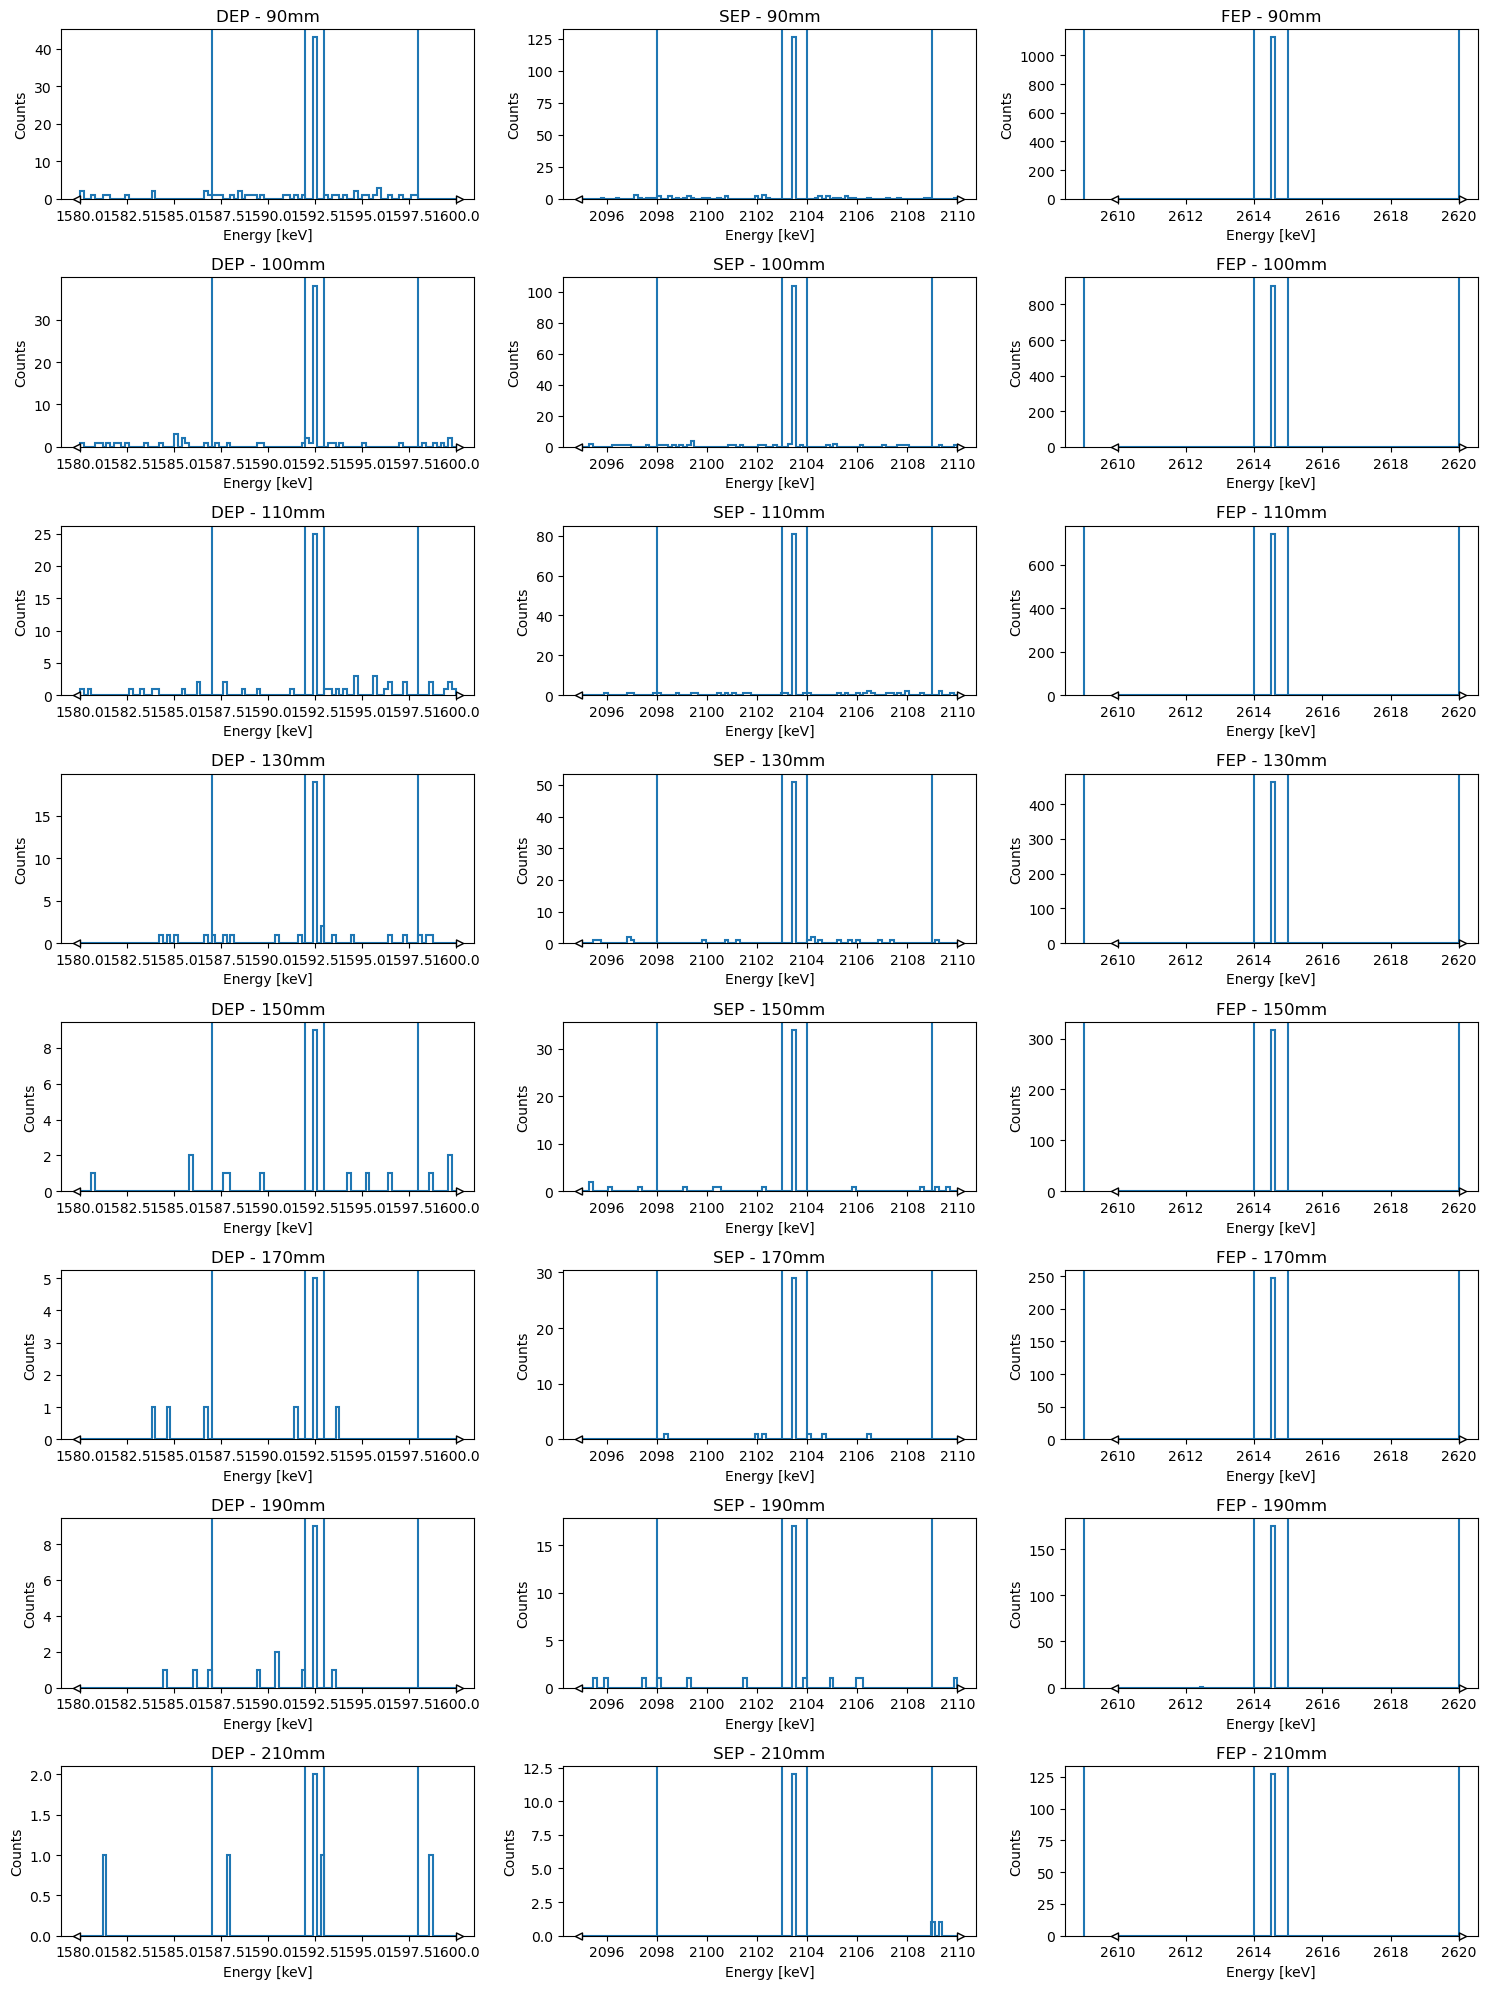

In [9]:
# check upper/lower energy bounds of peak windows and sideband windows

import matplotlib.pyplot as plt
import lgdo.lh5 as lh5
import awkward as ak
import hist

distances = ["90mm", "100mm", "110mm", "130mm", "150mm", "170mm", "190mm", "210mm"]

# peak windows [lower, upper] in keV
dep_window = [1580, 1600]  # ~1593 keV
sep_window = [2095, 2110]  # ~2103 keV
fep_window = [2610, 2620]  # ~2615 keV
sideband_window = 5 #keV

fig, ax = plt.subplots(len(distances), 3, figsize=(15, 20))

for i in range(len(distances)):
    # read data
    data = lh5.read_as("stp/det002", thorium_filepath + f"228Th_{distances[i]}.lh5", "ak")
    energies = ak.sum(data.edep, axis=-1)
    
    # DEP plot (left column)
    h_dep = hist.new.Reg(100, dep_window[0], dep_window[1], name="energy [keV]").Double().fill(energies)
    h_dep.plot(ax=ax[i, 0], yerr=False)
    ax[i, 0].set_title(f"DEP - {distances[i]}")
    ax[i, 0].set_xlabel("Energy [keV]")
    ax[i, 0].set_ylabel("Counts")
    ax[i, 0].axvline(1592)
    ax[i, 0].axvline(1593)

    ax[i, 0].axvline(1592-sideband_window)
    ax[i, 0].axvline(1593+sideband_window)
    
    # SEP plot (middle column)
    h_sep = hist.new.Reg(100, sep_window[0], sep_window[1], name="energy [keV]").Double().fill(energies)
    h_sep.plot(ax=ax[i, 1], yerr=False)
    ax[i, 1].set_title(f"SEP - {distances[i]}")
    ax[i, 1].set_xlabel("Energy [keV]")
    ax[i, 1].set_ylabel("Counts")
    ax[i, 1].axvline(2103)
    ax[i, 1].axvline(2104)

    ax[i, 1].axvline(2103-sideband_window)
    ax[i, 1].axvline(2104+sideband_window)
    
    # FEP plot (right column)
    h_fep = hist.new.Reg(100, fep_window[0], fep_window[1], name="energy [keV]").Double().fill(energies)
    h_fep.plot(ax=ax[i, 2], yerr=False)
    ax[i, 2].set_title(f"FEP - {distances[i]}")
    ax[i, 2].set_xlabel("Energy [keV]")
    ax[i, 2].set_ylabel("Counts")
    ax[i, 2].axvline(2614)
    ax[i, 2].axvline(2615)

    ax[i, 2].axvline(2614-sideband_window)
    ax[i, 2].axvline(2615+sideband_window)

plt.tight_layout()
plt.show()

In [10]:
distances = ["90mm", "100mm", "110mm", "130mm", "150mm", "170mm", "190mm", "210mm"]
det = "det002"

for dist in distances:
    print('dep', dist, side_band_subtract(1592, 1593, 5, thorium_filepath + f"228Th_{dist}.lh5", det))
    print('sep', dist, side_band_subtract(2103, 2104, 5, thorium_filepath + f"228Th_{dist}.lh5", det))
    print('fep', dist, side_band_subtract(2614, 2615, 5, thorium_filepath + f"228Th_{dist}.lh5", det))

dep 90mm 40.0
sep 90mm 122.4
fep 90mm 1126.7
dep 100mm 40.0
sep 100mm 104.6
fep 100mm 905.6
dep 110mm 23.0
sep 110mm 80.6
fep 110mm 741.8
dep 130mm 20.1
sep 130mm 49.8
fep 130mm 464.0
dep 150mm 8.4
sep 150mm 33.4
fep 150mm 317.0
dep 170mm 4.8
sep 170mm 28.4
fep 170mm 247.0
dep 190mm 8.5
sep 190mm 17.4
fep 190mm 174.9
dep 210mm 2.9
sep 210mm 12.0
fep 210mm 127.0


In [11]:
distances = ["90mm", "100mm", "110mm", "130mm", "150mm", "170mm", "190mm", "210mm"]
det = "det002"

for dist in distances:
    print(dist, total_counts(det, thorium_filepath + f"228Th_{dist}.lh5"))

90mm 52897
100mm 42527
110mm 34774
130mm 23558
150mm 16822
170mm 12302
190mm 9196
210mm 6930


In [13]:
print(total_counts(det, thorium_filepath + "228Th_95mm_try2.lh5"))
print('dep', side_band_subtract(1592, 1593, 5, thorium_filepath + "228Th_95mm_try2.lh5", det))
print('sep', side_band_subtract(2103, 2104, 5, thorium_filepath + "228Th_95mm_try2.lh5", det))
print('fep', side_band_subtract(2614, 2615, 5, thorium_filepath + "228Th_95mm_try2.lh5", det))

47329
dep 28.8
sep 120.0
fep 1095.7


In [14]:
print(total_counts(det, thorium_filepath + "228Th_90mm_try2.lh5"))
print('dep', side_band_subtract(1592, 1593, 5, thorium_filepath + "228Th_90mm_try2.lh5", det))
print('sep', side_band_subtract(2103, 2104, 5, thorium_filepath + "228Th_90mm_try2.lh5", det))
print('fep', side_band_subtract(2614, 2615, 5, thorium_filepath + "228Th_90mm_try2.lh5", det))

52727
dep 41.6
sep 125.3
fep 1161.4


# Americium-241

In [15]:
americium_filepath = "/Users/vyshnavisabbi/Documents/latte_geant4/simulation_data/Americium/" # path where lh5 files are located

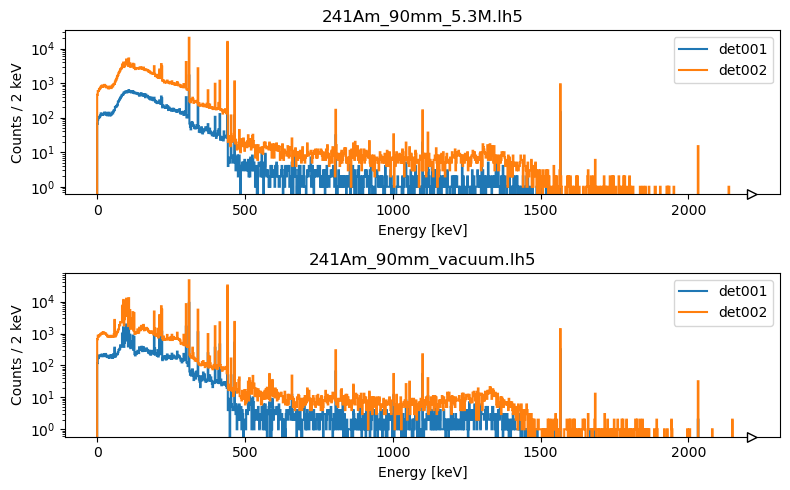

In [16]:
files = ["241Am_90mm_5.3M.lh5", "241Am_90mm_vacuum.lh5"]

fig, axes = plt.subplots(len(files), 1, figsize=(8, 2.5*len(files)))

bins, xmin, xmax = 1100, 0, 2200
for ax, file in zip(axes, files):
    plt.sca(ax)
    plot_edep("det001", bins, xmin, xmax, americium_filepath + file)
    plot_edep("det002", bins, xmin, xmax, americium_filepath + file)
    ax.set_ylabel("Counts / 2 keV") 
    ax.set_yscale("log")
    ax.legend()
    ax.set_title(file)

plt.tight_layout()
plt.show()

In [20]:
# total counts and peak counts for 241Am at 90 mm

am_file = americium_filepath + "241Am_90mm_5.3M.lh5"

print(total_counts('det001', am_file))
print(total_counts('det002', am_file))

print(side_band_subtract(1592, 1593, 5, am_file, 'det002'))
print(side_band_subtract(2103, 2104, 5, am_file, 'det002'))
print(side_band_subtract(2614, 2615, 5, am_file, 'det002'))

print(side_band_subtract(300, 301, 5, am_file, 'det002'))
print(side_band_subtract(311, 312, 5, am_file, 'det002'))
print(side_band_subtract(340, 341, 5, am_file, 'det002'))
print(side_band_subtract(375, 376, 5, am_file, 'det002'))
print(side_band_subtract(398, 399, 5, am_file, 'det002'))
print(side_band_subtract(415, 416, 5, am_file, 'det002'))

# negative numbers from side_band_subtract means that peak is attenuated or drowned out by noise

52626
337555
-0.6
0.0
0.0
3362.7
20029.2
2440.3
408.3
784.6
993.8


Turns out source was attenuated by source capsule, so didn't look into 241Am further

# Barium-133

In [21]:
barium_filepath = "/Users/vyshnavisabbi/Documents/latte_geant4/simulation_data/Barium/" # path where lh5 files are located

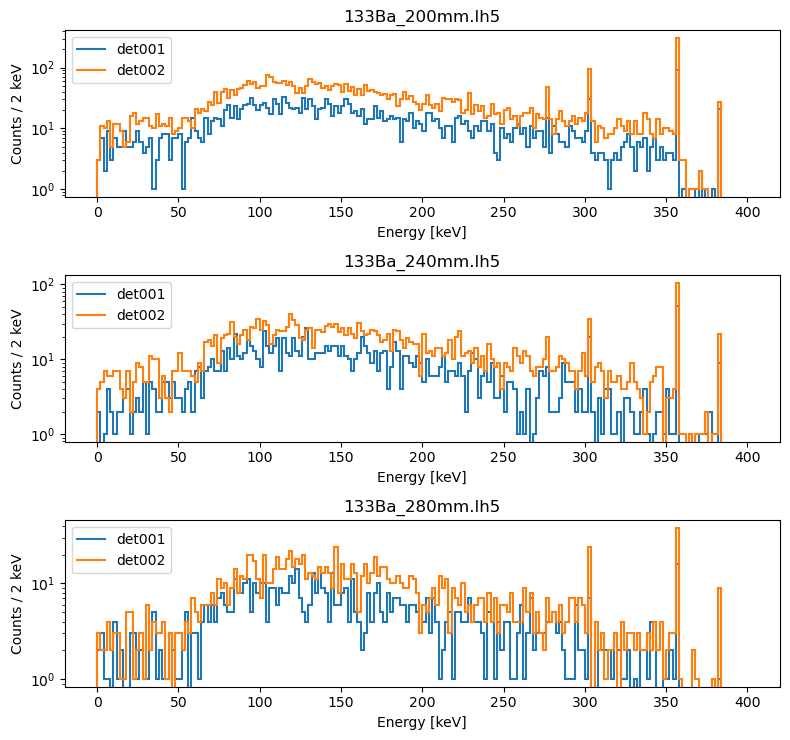

In [22]:
files = ["133Ba_200mm.lh5", "133Ba_240mm.lh5", "133Ba_280mm.lh5"] 

fig, axes = plt.subplots(len(files), 1, figsize=(8, 2.5*len(files)))

bins, xmin, xmax = 200, 0, 400
for ax, file in zip(axes, files):
    plt.sca(ax)
    plot_edep("det001", bins, xmin, xmax, barium_filepath + file)
    plot_edep("det002", bins, xmin, xmax, barium_filepath + file)
    ax.set_ylabel("Counts / 2 keV") 
    ax.set_yscale("log")
    ax.legend()
    ax.set_title(file)

plt.tight_layout()
plt.show()

In [23]:
#check various peak counts for 133Ba at 200 mm

ba_file = barium_filepath + "133Ba_200mm.lh5"
print(81, side_band_subtract(80, 81, 5, ba_file, 'det002'))
print(276, side_band_subtract(276, 277, 5, ba_file, 'det002'))
print(303, side_band_subtract(302, 303, 5, ba_file, 'det002'))
print(356, side_band_subtract(356, 357, 5, ba_file, 'det002'))
print(384, side_band_subtract(383, 384, 5, ba_file, 'det002'))

81 -4.699999999999999
276 34.3
303 86.2
356 305.0
384 27.0


In [28]:
# without sideband subtracting, to check background levels in peak window

ba_file = barium_filepath + "133Ba_200mm.lh5"

def peak_counts(detid, lower_peak, upper_peak):
    
    data = lh5.read_as(f"stp/{detid}", ba_file, "ak")
    energies = ak.sum(data.edep, axis=-1)

    peak_mask = (energies > lower_peak) & (energies < upper_peak)
    total = sum(peak_mask)

    return total


print("81 keV total peak counts: ", peak_counts('det002', 80, 82))

81 keV total peak counts:  32


In [29]:
distances = ["90mm", "95mm", "100mm", "110mm", "130mm", "150mm", "200mm", "240mm", "280mm", "285mm"]
det = "det002"

for dist in distances:
    print(dist, total_counts(det, barium_filepath + f"133Ba_{dist}.lh5"))

90mm 44850
95mm 39393
100mm 35021
110mm 27891
130mm 18213
150mm 12292
200mm 5060
240mm 2568
280mm 1373
285mm 1273


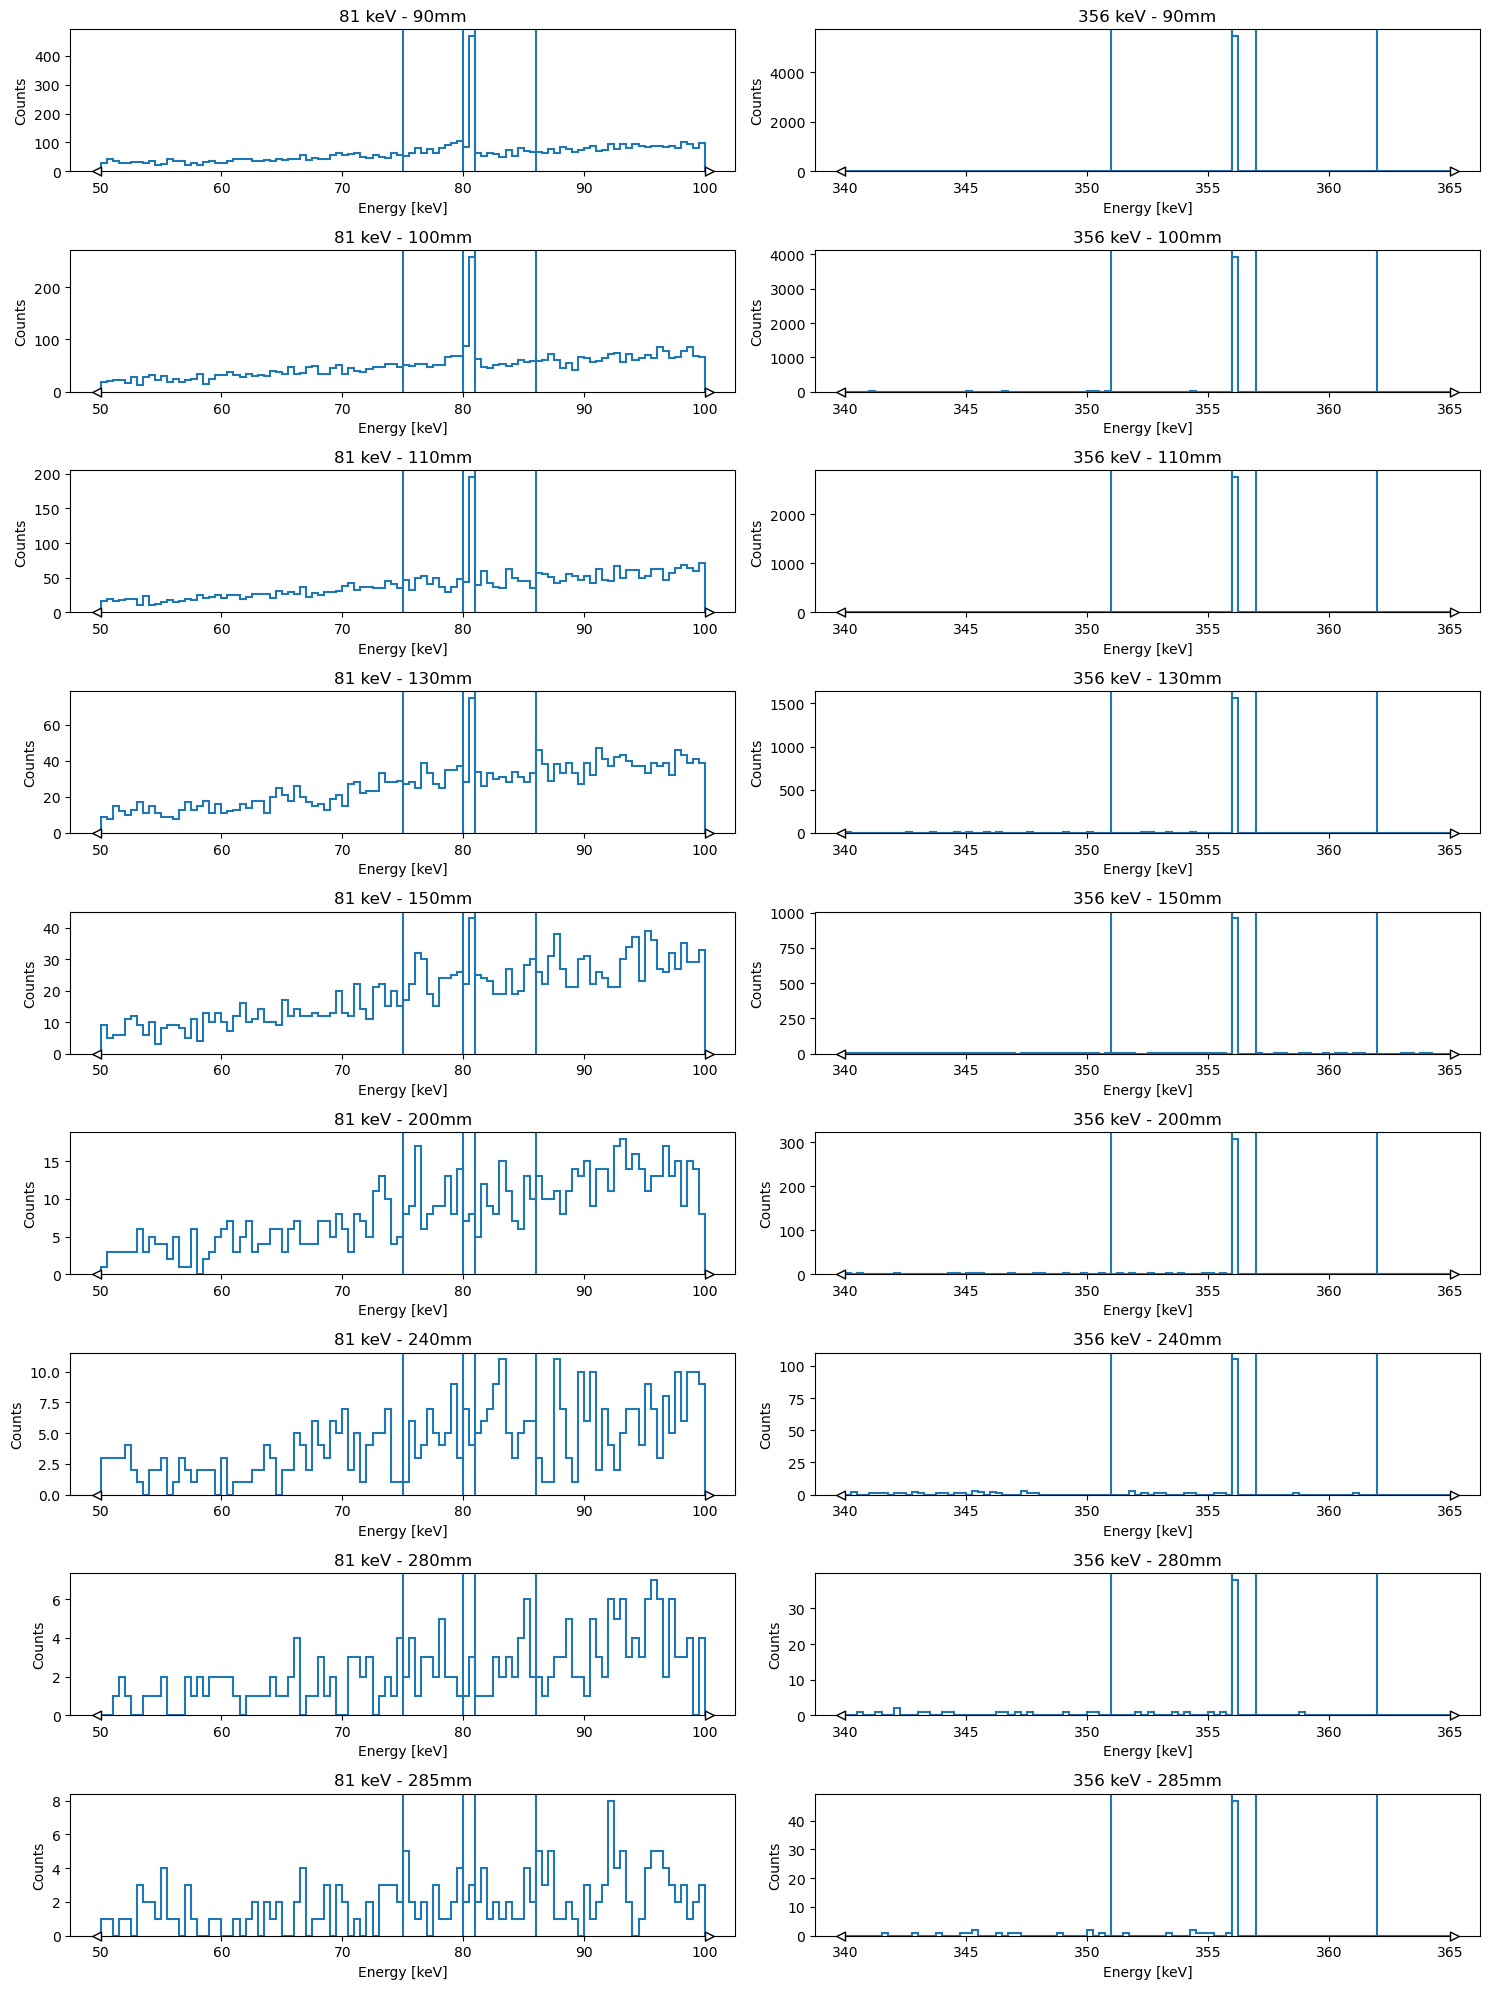

In [33]:
# check upper/lower energy bounds of peak windows and sideband windows

ba_distances = ["90mm", "100mm", "110mm", "130mm", "150mm", "200mm", "240mm", "280mm", "285mm"]

# peak windows [lower, upper] in keV
keV81_window = [50, 100]
keV356_window = [340, 365]

fig, ax = plt.subplots(len(ba_distances), 2, figsize=(15, 20))

for i in range(len(ba_distances)):
    # read data 
    data = lh5.read_as("stp/det002", barium_filepath + f"133Ba_{ba_distances[i]}.lh5", "ak")
    energies = ak.sum(data.edep, axis=-1)
    
    # 81keV plot (left column)
    h_dep = hist.new.Reg(100, keV81_window[0], keV81_window[1], name="Energy [keV]").Double().fill(energies)
    h_dep.plot(ax=ax[i, 0], yerr=False)
    ax[i, 0].set_title(f"81 keV - {ba_distances[i]}")
    ax[i, 0].set_xlabel("Energy [keV]")
    ax[i, 0].set_ylabel("Counts")
    ax[i, 0].axvline(80)
    ax[i, 0].axvline(81)

    ax[i, 0].axvline(80-5)
    ax[i, 0].axvline(81+5)
    
    # 356keV plot (right column)
    h_sep = hist.new.Reg(100, keV356_window[0], keV356_window[1], name="Energy [keV]").Double().fill(energies)
    h_sep.plot(ax=ax[i, 1], yerr=False)
    ax[i, 1].set_title(f"356 keV - {ba_distances[i]}")
    ax[i, 1].set_xlabel("Energy [keV]")
    ax[i, 1].set_ylabel("Counts")
    ax[i, 1].axvline(356)
    ax[i, 1].axvline(357)

    ax[i, 1].axvline(356-5)
    ax[i, 1].axvline(357+5)

plt.tight_layout()
plt.show()

In [37]:
# check peak counts for 133Ba at various distances

for dist in ba_distances:
    print('81 keV', dist, side_band_subtract(80, 81, 5, barium_filepath + f"133Ba_{dist}.lh5", "det002"))
    print('356 keV', dist, side_band_subtract(356, 357, 5, barium_filepath + f"133Ba_{dist}.lh5", "det002"))

81 keV 90mm 409.6
356 keV 90mm 5433.4
81 keV 100mm 234.4
356 keV 100mm 3921.2
81 keV 110mm 151.5
356 keV 110mm 2742.3
81 keV 130mm 41.1
356 keV 130mm 1557.9
81 keV 150mm 18.200000000000003
356 keV 150mm 955.4
81 keV 200mm -4.699999999999999
356 keV 200mm 305.0
81 keV 240mm 0.0
356 keV 240mm 103.8
81 keV 280mm -1.0
356 keV 280mm 37.3
81 keV 285mm 0.9000000000000004
356 keV 285mm 46.2


In [38]:
det = "det002"

for dist in distances:
    print(dist, total_counts(det, barium_filepath + f"133Ba_{dist}.lh5"))

90mm 44850
95mm 39393
100mm 35021
110mm 27891
130mm 18213
150mm 12292
200mm 5060
240mm 2568
280mm 1373
285mm 1273
